<a href="https://colab.research.google.com/github/PabloDuranL/Miprogresionypraticas/blob/main/KernelRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [105]:
np.random.seed(123)

In [106]:
N=40
x=np.sort(np.random.rand(N))
e=np.random.normal(0,0.02,N)
y=np.sin(2*np.pi*x)+e


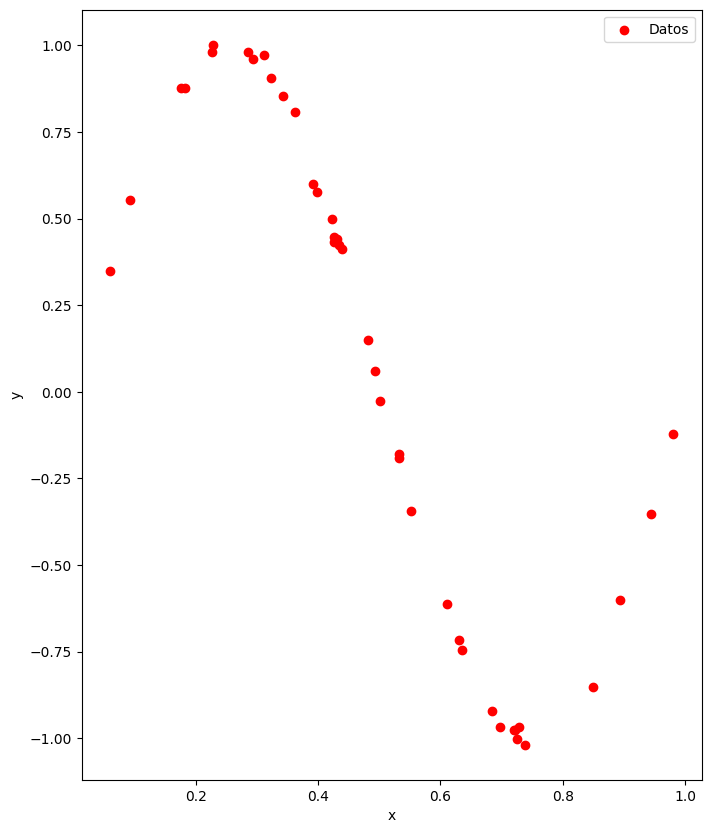

In [107]:

plt.figure(figsize=(8,10))
plt.scatter(x,y,color="red",label="Datos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [108]:
def RBF(x,centro, sigma):
  return np.exp(-(x-centro)**2/(2*sigma**2))


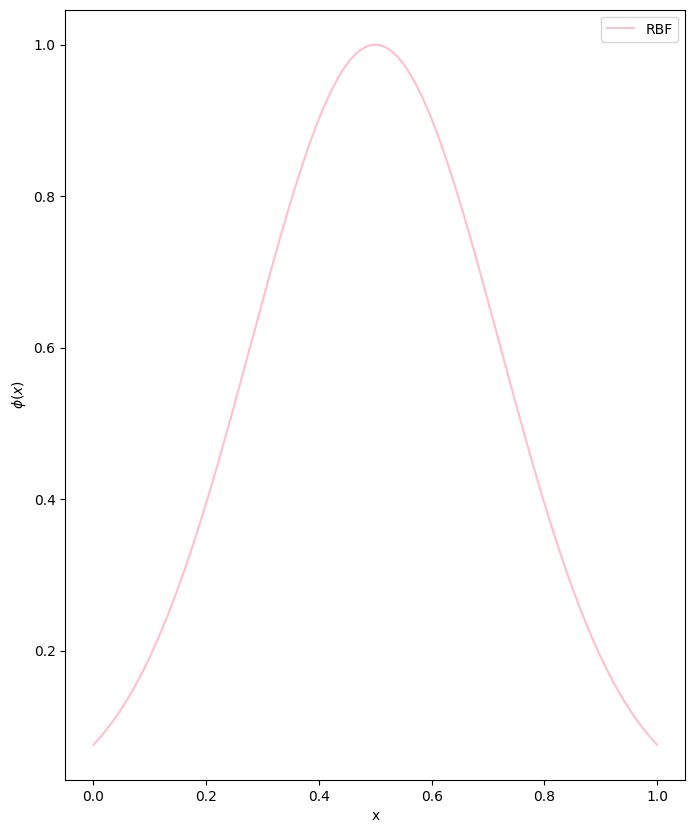

In [109]:
X=np.linspace(0,1,300)
phi= RBF(X,0.5,0.22)
plt.figure(figsize=(8,10))
plt.plot(X,phi,color='pink',label='RBF')
plt.xlabel('x')
plt.ylabel(r"$\phi(x)$")
plt.legend()
plt.show()

In [110]:
M=10
centros=np.random.rand(M)
sigma=0.10

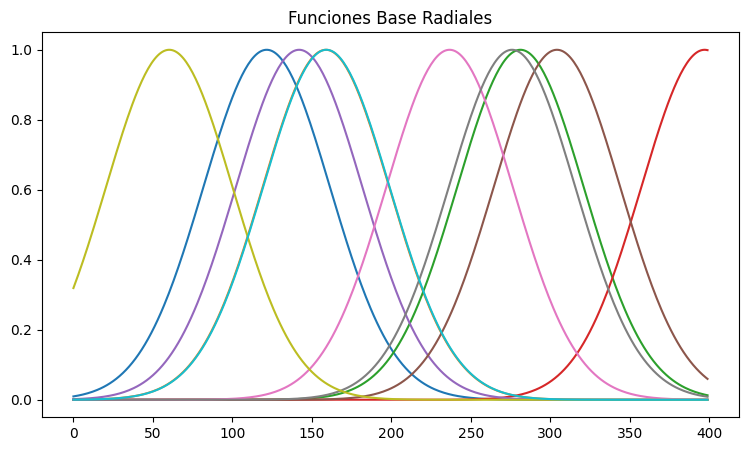

In [111]:
X=np.linspace(0,1,400)

plt.figure(figsize=(9,5))

for c in centros:
    plt.plot(RBF(X,c,sigma))

plt.title("Funciones Base Radiales")

plt.show()

In [112]:
def matriz_design(x,centros,sigma):
  phi=np.zeros((int(len(x)),int(len(centros))))
  for i,c in enumerate(centros):
    phi[:,i]=RBF(x,c,sigma)
  return phi

In [113]:
phi=matriz_design(x,centros,sigma)
phi.shape

(40, 10)

In [114]:
w=np.linalg.inv(phi.T@phi)@phi.T@y

In [115]:
x_grid=np.linspace(0,1,300)
phi_test=matriz_design(x_grid,centros,sigma)
y_pred=phi_test@w


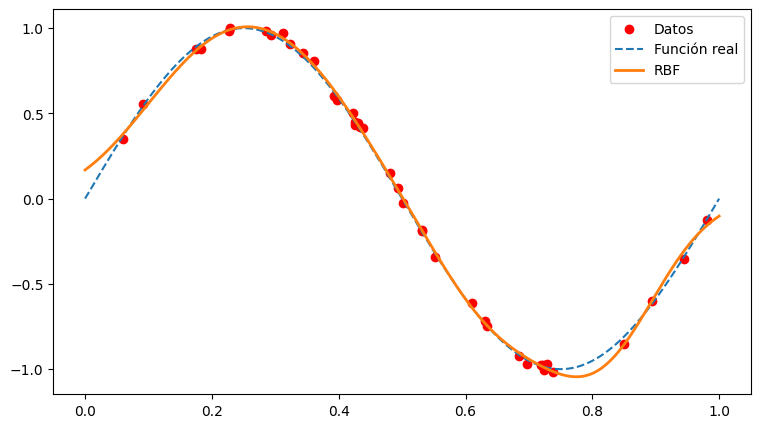

In [116]:
plt.figure(figsize=(9,5))

plt.scatter(x,y,color="red",label="Datos")

plt.plot(x_grid,
         np.sin(2*np.pi*x_grid),
         '--',
         label="Función real")

plt.plot(x_grid,
         y_pred,
         linewidth=2,
         label="RBF")

plt.legend()

plt.show()